# 🔬 InsectIQ — Smart Insect Identifier
## Training Notebook: EfficientNet-B3 Transfer Learning
**Framework:** PyTorch | **Dataset:** Insect Classification (Kaggle)

In [42]:
# Install dependencies (Kaggle environment)
!pip install -q timm torchinfo

In [43]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import timm

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torchinfo import summary

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
Using device    : cuda


## 1. Configuration

In [44]:
# ============================================================
# CONFIGURATION
# Dataset structure:
#   /kaggle/input/insects/dataset/train/<class>/*.jpg
#   /kaggle/input/insects/dataset/val/<class>/**.jpg
#   /kaggle/input/insects/dataset/test/<class>/*.jpg
# ============================================================
CONFIG = {
    'train_dir'          : '/kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/train',
    'val_dir'            : '/kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/val',
    'test_dir'           : '/kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/test',
    'output_dir'         : '/kaggle/working/artifacts',
    'model_name'         : 'efficientnet_b3',
    'img_size'           : 300,
    'batch_size'         : 32,
    'num_epochs'         : 50,
    'lr'                 : 1e-4,
    'weight_decay'       : 1e-4,
    'early_stop_patience': 7,
    'seed'               : 42,
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
print('Config loaded ✓')

Config loaded ✓


## 2. Dataset — Corrupt Image Handling & Loading

In [45]:
def scan_and_filter_images(data_dir, class_to_idx=None):
    """
    Scan a split directory, skip corrupted images.
    If class_to_idx is provided, use it (so train/val/test share same label mapping).
    Returns: valid_paths, valid_labels, class_names, class_to_idx
    """
    data_dir = Path(data_dir)
    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])

    if class_to_idx is None:
        class_to_idx = {cls: i for i, cls in enumerate(class_names)}

    valid_paths, valid_labels = [], []
    corrupt_count = 0

    for cls in class_names:
        cls_dir = data_dir / cls
        if not cls_dir.exists():
            continue
        for img_path in cls_dir.glob('*'):
            if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:
                continue
            try:
                with Image.open(img_path) as img:
                    img.verify()
                with Image.open(img_path) as img:
                    img.convert('RGB')
                valid_paths.append(str(img_path))
                valid_labels.append(class_to_idx[cls])
            except Exception:
                corrupt_count += 1

    print(f'  Classes : {len(class_names)}')
    print(f'  Valid   : {len(valid_paths)}')
    print(f'  Corrupt : {corrupt_count} (skipped)')
    return valid_paths, valid_labels, class_names, class_to_idx


print('Scanning train set...')
train_paths, train_labels, CLASS_NAMES, CLASS_TO_IDX = scan_and_filter_images(CONFIG['train_dir'])

print('Scanning val set...')
val_paths, val_labels, _, _ = scan_and_filter_images(CONFIG['val_dir'], CLASS_TO_IDX)

print('Scanning test set...')
test_paths, test_labels, _, _ = scan_and_filter_images(CONFIG['test_dir'], CLASS_TO_IDX)

NUM_CLASSES = len(CLASS_NAMES)
print(f'\nTotal classes  : {NUM_CLASSES}')
print(f'Train / Val / Test : {len(train_paths)} / {len(val_paths)} / {len(test_paths)}')
print(f'Class list: {CLASS_NAMES}')

Scanning train set...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


  Classes : 118
  Valid   : 90105
  Corrupt : 10 (skipped)
Scanning val set...
  Classes : 118
  Valid   : 11212
  Corrupt : 3 (skipped)
Scanning test set...
  Classes : 118
  Valid   : 11360
  Corrupt : 3 (skipped)

Total classes  : 118
Train / Val / Test : 90105 / 11212 / 11360
Class list: ['adristyrannus', 'aleurocanthus spiniferus', 'alfalfa plant bug', 'alfalfa seed chalcid', 'alfalfa weevil', 'ampelophaga', 'ant', 'aphids', 'apolygus lucorum', 'armyworm', 'asiatic rice borer', 'bactrocera tsuneonis', 'bee', 'beet fly', 'beetle', 'black cutworm', 'blister beetle', 'bollworm', 'brevipoalpus lewisi McGregor', 'brown plant hopper', 'butterfly', 'catterpillar', 'cerodonta denticornis', 'ceroplastes rubens', 'chayon', 'chlumetia transversa', 'chrysomphalus aonidum', 'cicadella viridis', 'cicadellidae', 'corn borer', 'dacus dorsalis(Hendel)', 'dasineura sp', 'deporaus marginatus Pascoe', 'dragonfly', 'earthworm', 'earwig', 'erythroneura apicalis', 'fall armyworm', 'flax budworm', 'flea 

In [46]:
# Save class metadata
metadata = {
    'class_names' : CLASS_NAMES,
    'class_to_idx': CLASS_TO_IDX,
    'num_classes' : NUM_CLASSES,
    'img_size'    : CONFIG['img_size'],
    'model_name'  : CONFIG['model_name'],
}
with open(f"{CONFIG['output_dir']}/metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)
print('Metadata saved ✓')

Metadata saved ✓


## 3. Data Augmentation & Transforms

In [47]:
IMG_SIZE = CONFIG['img_size']

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

print('Transforms defined ✓')

Transforms defined ✓


In [48]:
class InsectDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Use official splits — no manual splitting needed
train_ds = InsectDataset(train_paths, train_labels, train_transforms)
val_ds   = InsectDataset(val_paths,   val_labels,   val_transforms)
test_ds  = InsectDataset(test_paths,  test_labels,  val_transforms)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

print(f'Train loader : {len(train_ds)} images | {len(train_loader)} batches')
print(f'Val loader   : {len(val_ds)} images   | {len(val_loader)} batches')
print(f'Test loader  : {len(test_ds)} images  | {len(test_loader)} batches')

Train loader : 90105 images | 2816 batches
Val loader   : 11212 images   | 351 batches
Test loader  : 11360 images  | 355 batches


## 4. Model — EfficientNet-B3 (Transfer Learning)

In [49]:
def build_model(num_classes, pretrained=True):
    model = timm.create_model(
        CONFIG['model_name'],
        pretrained=pretrained,
        num_classes=num_classes,
        drop_rate=0.3,
        drop_path_rate=0.2,
    )
    return model

model = build_model(NUM_CLASSES).to(DEVICE)
summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), device=str(DEVICE))

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Layer (type:depth-idx)                        Output Shape              Param #
EfficientNet                                  [1, 118]                  --
├─Conv2d: 1-1                                 [1, 40, 150, 150]         1,080
├─BatchNormAct2d: 1-2                         [1, 40, 150, 150]         80
│    └─Identity: 2-1                          [1, 40, 150, 150]         --
│    └─SiLU: 2-2                              [1, 40, 150, 150]         --
├─Sequential: 1-3                             [1, 384, 10, 10]          --
│    └─Sequential: 2-3                        [1, 24, 150, 150]         --
│    │    └─DepthwiseSeparableConv: 3-1       [1, 24, 150, 150]         2,298
│    │    └─DepthwiseSeparableConv: 3-2       [1, 24, 150, 150]         1,206
│    └─Sequential: 2-4                        [1, 32, 75, 75]           --
│    │    └─InvertedResidual: 3-3             [1, 32, 75, 75]           11,878
│    │    └─InvertedResidual: 3-4             [1, 32, 75, 75]           18,120
│  

## 5. Training with Early Stopping

In [50]:
class EarlyStopping:
    def __init__(self, patience=7, delta=1e-4):
        self.patience    = patience
        self.delta       = delta
        self.best_loss   = float('inf')
        self.counter     = 0
        self.should_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

print('Training utilities defined ✓')

Training utilities defined ✓


In [51]:
criterion      = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer      = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler      = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['num_epochs'])
scaler         = torch.cuda.amp.GradScaler()
early_stopping = EarlyStopping(patience=CONFIG['early_stop_patience'])

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc    = 0.0
best_model_path = f"{CONFIG['output_dir']}/best_model.pth"

print('Starting training...')
for epoch in range(1, CONFIG['num_epochs'] + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    is_best = vl_acc > best_val_acc
    if is_best:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_model_path)

    print(f'Epoch [{epoch:03d}/{CONFIG["num_epochs"]}] '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}'
          f'{" ← best" if is_best else ""}')

    if early_stopping(vl_loss):
        print(f'Early stopping triggered at epoch {epoch}')
        break

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Starting training...


/tmp/ipykernel_58/3181908592.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler         = torch.cuda.amp.GradScaler()
/tmp/ipykernel_58/3604345544.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [001/50] Train Loss: 2.3241 Acc: 0.5794 | Val Loss: 1.6625 Acc: 0.7434 ← best
Epoch [002/50] Train Loss: 1.6967 Acc: 0.7354 | Val Loss: 1.5157 Acc: 0.7859 ← best
Epoch [003/50] Train Loss: 1.5311 Acc: 0.7808 | Val Loss: 1.4512 Acc: 0.8007 ← best
Epoch [004/50] Train Loss: 1.4316 Acc: 0.8090 | Val Loss: 1.4150 Acc: 0.8181 ← best
Epoch [005/50] Train Loss: 1.3590 Acc: 0.8304 | Val Loss: 1.3903 Acc: 0.8239 ← best
Epoch [006/50] Train Loss: 1.3017 Acc: 0.8473 | Val Loss: 1.3813 Acc: 0.8244 ← best
Epoch [007/50] Train Loss: 1.2509 Acc: 0.8640 | Val Loss: 1.3725 Acc: 0.8308 ← best
Epoch [008/50] Train Loss: 1.2127 Acc: 0.8769 | Val Loss: 1.3690 Acc: 0.8326 ← best
Epoch [009/50] Train Loss: 1.1802 Acc: 0.8856 | Val Loss: 1.3699 Acc: 0.8334 ← best
Epoch [010/50] Train Loss: 1.1512 Acc: 0.8955 | Val Loss: 1.3751 Acc: 0.8334
Epoch [011/50] Train Loss: 1.1255 Acc: 0.9038 | Val Loss: 1.3630 Acc: 0.8360 ← best
Epoch [012/50] Train Loss: 1.1018 Acc: 0.9114 | Val Loss: 1.3625 Acc: 0.8401 ← best

## 6. Evaluation — Accuracy, Report, Confusion Matrix, Curves

In [52]:
# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_labels_eval = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_eval.extend(labels.numpy())

test_acc = accuracy_score(all_labels_eval, all_preds)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print()
print(classification_report(all_labels_eval, all_preds, target_names=CLASS_NAMES))

Test Accuracy: 0.8417 (84.17%)

                                 precision    recall  f1-score   support

                  adristyrannus       0.89      0.78      0.83        32
       aleurocanthus spiniferus       0.94      0.84      0.89        69
              alfalfa plant bug       0.52      0.49      0.50        67
           alfalfa seed chalcid       0.29      0.21      0.24        19
                 alfalfa weevil       0.79      0.58      0.67        53
                    ampelophaga       0.81      0.87      0.84        77
                            ant       0.96      0.99      0.98       193
                         aphids       0.86      0.92      0.89       620
               apolygus lucorum       0.67      0.46      0.55        39
                       armyworm       0.73      0.73      0.73       353
             asiatic rice borer       0.69      0.70      0.69       106
           bactrocera tsuneonis       0.62      0.28      0.38        18
                  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [53]:
# Confusion Matrix
cm = confusion_matrix(all_labels_eval, all_preds)
fig_size = max(12, NUM_CLASSES)
fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/confusion_matrix.png", dpi=150)
plt.show()
print('Confusion matrix saved ✓')

Confusion matrix saved ✓


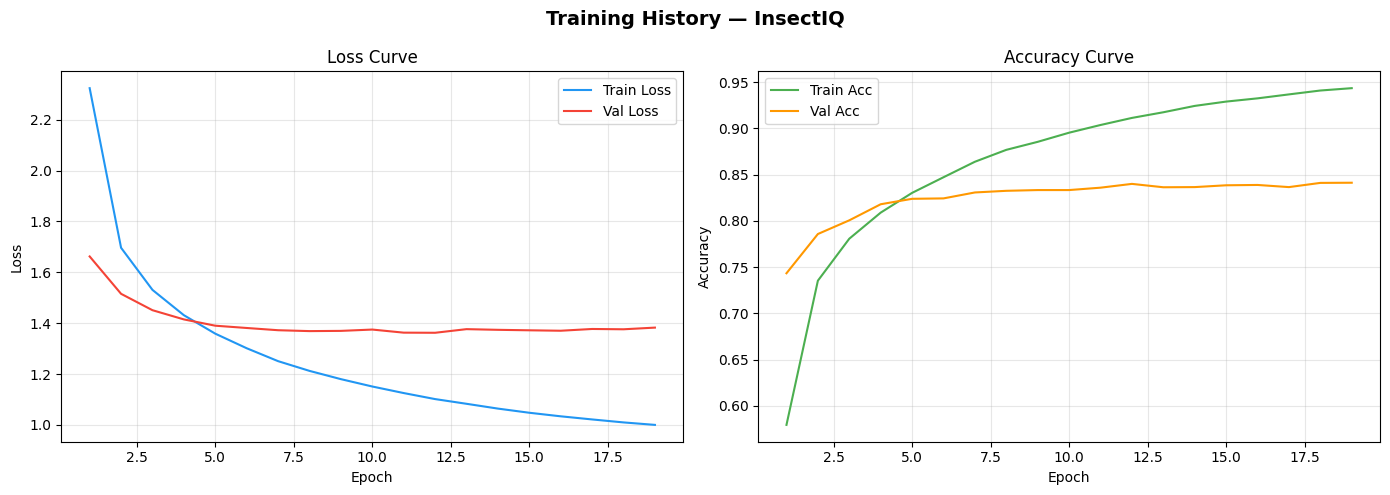

Training curves saved ✓


In [54]:
# Training & Validation Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='#2196F3')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='#F44336')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', color='#4CAF50')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   color='#FF9800')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training History — InsectIQ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/training_curves.png", dpi=150)
plt.show()
print('Training curves saved ✓')

## 7. Export Model (TorchScript)

In [57]:
model.eval()
model_cpu   = model.cpu()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

scripted    = torch.jit.trace(model_cpu, dummy_input)
script_path = f"{CONFIG['output_dir']}/model_scripted.pt"
torch.jit.save(scripted, script_path)

print(f'TorchScript model → {script_path}')
print(f'State dict model  → {best_model_path}')
print(f'Metadata          → {CONFIG["output_dir"]}/metadata.json')
print('\n✅ All artifacts saved! Download from /kaggle/working/artifacts/')

TorchScript model → /kaggle/working/artifacts/model_scripted.pt
State dict model  → /kaggle/working/artifacts/best_model.pth
Metadata          → /kaggle/working/artifacts/metadata.json

✅ All artifacts saved! Download from /kaggle/working/artifacts/


In [58]:
from IPython.display import FileLink
import torch

model.eval()
model_cpu = model.cpu()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

scripted = torch.jit.trace(model_cpu, dummy_input)
torch.jit.save(scripted, '/kaggle/working/artifacts/model_scripted.pt')

print('Saved!')
display(FileLink('/kaggle/working/artifacts/model_scripted.pt'))

Saved!


/kaggle/working/artifacts/model_scripted.pt

In [60]:
import os
os.system('cp /kaggle/working/artifacts/model_scripted.pt /kaggle/working/model_scripted.pt')
from IPython.display import FileLink
display(FileLink('/kaggle/working/model_scripted.pt'))

/kaggle/working/model_scripted.pt